# Validation: observed data | Neural SDE teacher | Symbolic SDE
Same measured initial states, matched explicit Brownian seeds 202/203/204, Itô Euler dt0.05 and dt0.025 sensitivity. Fate readout uses a 15-neighbor classifier fitted on symbolic training observations only. Test never selects library/threshold. Teacher exposure and upstream PCA remain limitations.

Frozen polynomial simulation failed: failed mass remains explicit. Full distribution distances/moments are unavailable when paths are nonfinite; survivor scatter is a biased diagnostic only.

In [1]:
from pathlib import Path
import os,sys,json
ROOT=Path.cwd()
if ROOT.name=='notebooks':ROOT=ROOT.parent
os.chdir(ROOT);sys.path.insert(0,str(ROOT))
import pandas as pd,numpy as np
from IPython.display import display,Image,Markdown


In [2]:
root=Path('outputs/validation_pc5')
result=json.loads((root/'results.json').read_text())
result

{'simulation_success': False,
 'seeds': [202, 203, 204],
 'initial_observed_cells': 32,
 'replicates_per_initial': 4,
 'dt': 0.05,
 'dt_halving_endpoint_distance': {'Neural SDE teacher': {'endpoint_sliced_wasserstein': 0.03542323983534833,
   'coarse_and_fine_finite': True},
  'Symbolic SDE': {'endpoint_sliced_wasserstein': None,
   'coarse_and_fine_finite': False}},
 'teacher_symbolic_day6_total_variation_with_failure_mass': 0.7135416666666666,
 'full_fate_distribution_preservation_evaluable': False,
 'fate_classifier_test_accuracy': 0.945516458569807,
 'fate_preservation_demo': False,
 'symbolic_day6_numerical_failure_fraction': 0.5859375,
 'interpretation': 'Negative simulation results are retained. No model tuning was performed using these test results.',
 'caveats': ['Teacher exposure and upstream PCA prevent independent biological confirmation.',
  'Only 32 initial cells and three Brownian seeds; simulated data are not new observations.',
  'Missing full distribution distances/mo

stability.csv


,source,seed,finite,max_finite_state_norm,nonfinite_path_fraction,evaluated_time_explosion_or_nonfinite_path_fraction,explosion_threshold,evaluated_time_outside_training_domain_fraction,exception
0,Neural SDE teacher,202,True,2.318444e+01,0.000000,0.000000,254.602795,0.000000,NaN
1,Neural SDE teacher,203,True,2.284190e+01,0.000000,0.000000,254.602795,0.000000,NaN
2,Neural SDE teacher,204,True,2.271319e+01,0.000000,0.000000,254.602795,0.000000,NaN
3,Symbolic SDE,202,False,1.038548e+34,0.289062,0.578125,254.602795,0.307292,NaN
4,Symbolic SDE,203,False,4.601567e+36,0.265625,0.578125,254.602795,0.309896,NaN
5,Symbolic SDE,204,False,1.462953e+37,0.265625,0.601562,254.602795,0.307292,NaN


distribution_distances.csv


,time,source,n_cells_or_simulations,numerically_failed_fraction,full_distribution_available,sliced_wasserstein_to_observed,sliced_wasserstein_to_teacher
0,2.0,Observed data,37,0.000000,True,0.000000,0.053763
1,2.0,Neural SDE teacher,384,0.000000,True,0.053763,0.000000
2,2.0,Symbolic SDE,384,0.000000,True,0.053763,0.000000
3,4.0,Observed data,605,0.000000,True,0.000000,0.252652
4,4.0,Neural SDE teacher,384,0.000000,True,0.252652,0.000000
5,4.0,Symbolic SDE,384,0.000000,True,1.069629,1.067975
6,6.0,Observed data,1120,0.000000,True,0.000000,0.376509
7,6.0,Neural SDE teacher,384,0.000000,True,0.376509,0.000000
8,6.0,Symbolic SDE,384,0.585938,False,NaN,NaN


fate_composition.csv


,time,source,fate,fraction
0,2.0,Observed data,Monocyte,0.000000
1,2.0,Observed data,Neutrophil,0.000000
2,2.0,Observed data,Undifferentiated,1.000000
3,2.0,Observed data,Numerical failure,0.000000
4,2.0,Neural SDE teacher,Monocyte,0.000000
5,2.0,Neural SDE teacher,Neutrophil,0.000000
6,2.0,Neural SDE teacher,Undifferentiated,1.000000
7,2.0,Neural SDE teacher,Numerical failure,0.000000
8,2.0,Symbolic SDE,Monocyte,0.000000
9,2.0,Symbolic SDE,Neutrophil,0.000000


moments.csv


,time,source,full_distribution_available,mean_norm,covariance_trace,mean_error_to_observed_training_scaled,covariance_error_to_observed_training_scaled,covariance_error_to_teacher_training_scaled
0,2.0,Observed data,True,6.699971,9.984060,6.502605e-08,0.000000,0.068953
1,2.0,Neural SDE teacher,True,6.641588,10.261806,1.154686e-01,0.068953,0.000000
2,2.0,Symbolic SDE,True,6.641588,10.261806,1.154686e-01,0.068953,0.000000
3,4.0,Observed data,True,3.559938,54.016573,2.823736e-07,0.000000,0.909771
4,4.0,Neural SDE teacher,True,3.672138,21.077043,4.307064e-01,0.909771,0.000000
5,4.0,Symbolic SDE,True,9.877110,90.547898,2.334872e+00,1.997873,2.318832
6,6.0,Observed data,True,6.389363,113.399940,1.621807e-06,0.000000,2.101542
7,6.0,Neural SDE teacher,True,9.183798,144.092808,7.728021e-01,2.101542,0.000000
8,6.0,Symbolic SDE,False,NaN,NaN,NaN,NaN,NaN


observed_function_fidelity.csv


,partition,target,mse,nrmse,cosine_mean,error_norm_q95,error_norm_max
0,train,drift,3.078514,0.419561,0.938308,6.553091,92.677654
1,train,G,0.001288,0.283364,0.850695,0.131080,2.330568
2,train,D=GG^T,0.001217,1.147855,0.796245,0.081368,13.232082
3,validation,drift,2.709877,0.384588,0.940527,6.576586,22.067427
4,validation,G,0.001382,0.277746,0.835142,0.138344,0.722254
5,validation,D=GG^T,0.000110,0.369396,0.781280,0.100030,0.785923
6,test,drift,2.968798,0.430789,0.924169,6.705703,24.654663
7,test,G,0.001213,0.293090,0.837048,0.133896,0.502806
8,test,D=GG^T,0.000094,0.369922,0.779144,0.091279,0.749043


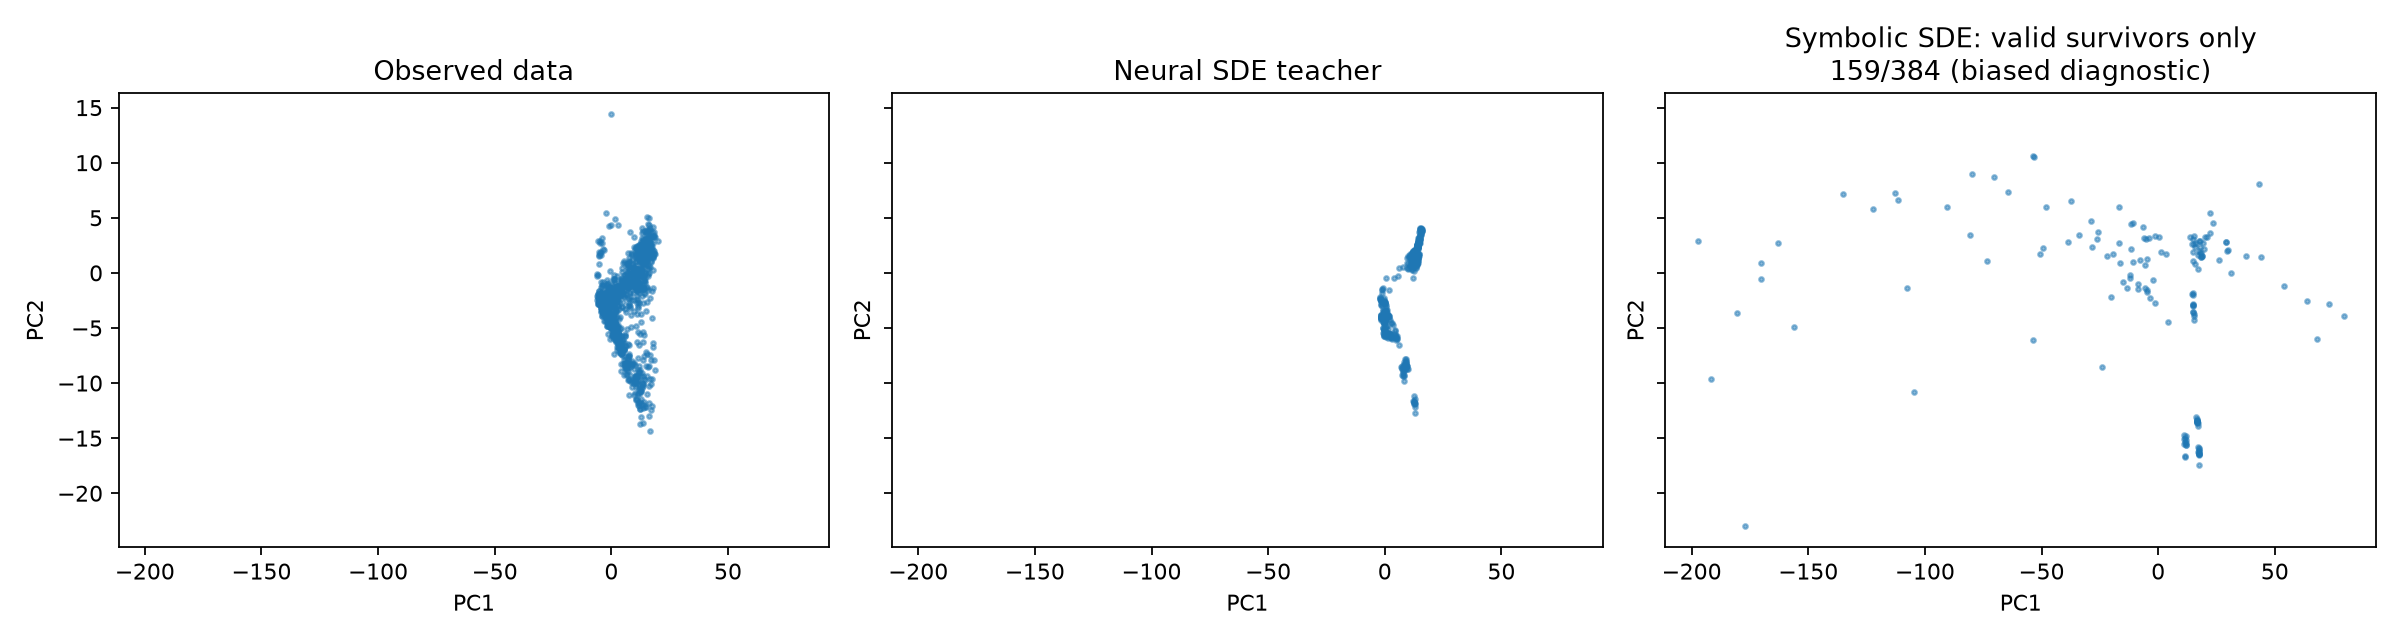

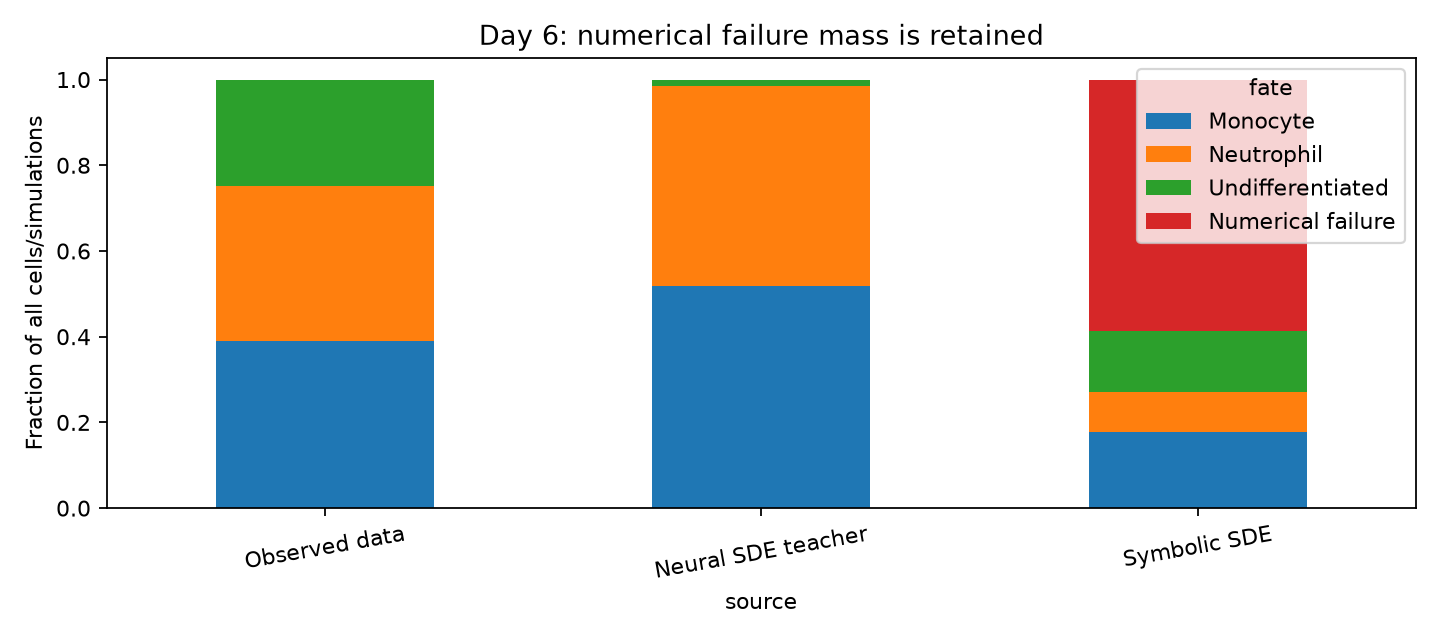

In [3]:
for filename in ('stability.csv','distribution_distances.csv','fate_composition.csv','moments.csv','observed_function_fidelity.csv'):
    print(filename);display(pd.read_csv(root/filename))
display(Image(filename='outputs/figures/pc5_endpoint_comparison.png'))
display(Image(filename='outputs/figures/pc5_fate_comparison.png'))

In [4]:
direct=Path('outputs/direct_baseline_pc5')
display(pd.read_csv(direct/'test_displacement_comparison.csv'))
print(json.loads((direct/'results.json').read_text())['assumptions'])
display(pd.read_csv('outputs/direct_baseline/test_displacement_comparison.csv'))

,source,mse,nrmse,cosine_mean,error_norm_q95,error_norm_max
0,Raw clone-centroid polynomial proxy,13.401178,0.830565,0.855457,14.39742,21.654719
1,Neural SDE teacher,22.979071,1.087598,0.724775,20.35849,31.011621
2,Symbolic SDE,27.833113,1.196970,0.608423,20.00437,30.790997


['Different cells share a clone barcode, not a continuous individual trajectory.', 'Centroid change reflects sampling, branching and growth as well as dynamics.', 'Raw proxy predicts a finite two-day displacement via Euler; SDE predictions use integrated sample means.', 'Teacher fit exposure and upstream PCA preclude fully independent biological inference.', 'This is a qualified drift proxy and not a fair stochastic-SINDy benchmark or evidence of superiority.']


,source,mse,nrmse,cosine_mean,error_norm_q95,error_norm_max
0,Raw clone-centroid polynomial proxy,2.310580,0.842796,0.754071,17.660320,24.591227
1,Neural SDE teacher,3.043664,0.967298,0.595760,21.992981,34.803429


The raw baseline is a clone-centroid finite-two-day displacement proxy, not direct stochastic SINDy on individual trajectories. Its assumptions include branching, growth and sampling effects. Diffusion cannot fairly be estimated from these centroid pairs alone; no Brownian factor is fabricated. This comparison cannot establish superiority over valid stochastic SINDy. In the 50-PC proxy comparison, the raw proxy outperformed the teacher on that metric.

Polynomial function fidelity is insufficient evidence of distribution fidelity. Keep simulation failures, outside-domain occupancy, fate composition error and discrepancies to observed snapshots. A preserved teacher distribution is still a teacher approximation, not gene regulation or causal discovery. See final report for M0–M4 judgments and negative results.

The numerical-failure category is a computational status, not biological cell death. M3/M4 are not achieved by the current symbolic model. No test-driven refitting or clipping was used.